In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875


In [2]:
df.shape

(418, 10)

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
dtypes: float64(2), int64(5), str(3)
memory usage: 32.8 KB


PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
dtype: int64

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [5]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare']


In [6]:
print(df.isnull().sum())

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            1
dtype: int64


In [7]:
import pandas as pd

df = pd.read_csv("data/titanic.csv")

print(df.columns)
print(df.shape)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare'],
      dtype='str')
(418, 10)


In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875


In [9]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare']


In [10]:
# Fill Age if it exists
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

# Handle Cabin if it exists
if "Cabin" in df.columns:
    df["CabinKnown"] = df["Cabin"].notna().astype(int)
    df.drop("Cabin", axis=1, inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check remaining missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
dtype: int64


In [11]:
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

if "Cabin" in df.columns:
    df["CabinKnown"] = df["Cabin"].notna().astype(int)
    df.drop("Cabin", axis=1, inplace=True)

df.drop_duplicates(inplace=True)

print("Cleaning completed!")

Cleaning completed!


In [12]:
if "SibSp" in df.columns and "Parch" in df.columns:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

if "Age" in df.columns:
    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[0, 12, 18, 35, 60, 100],
        labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
    )

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,AgeGroup
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,1,1,Young Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,2,0,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,1,1,Senior
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,1,1,Young Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,3,0,Young Adult


In [13]:
df.to_csv("data/titanic_cleaned.csv", index=False)

print("✅ Cleaned dataset saved!")

✅ Cleaned dataset saved!


In [14]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'FamilySize', 'IsAlone', 'AgeGroup']


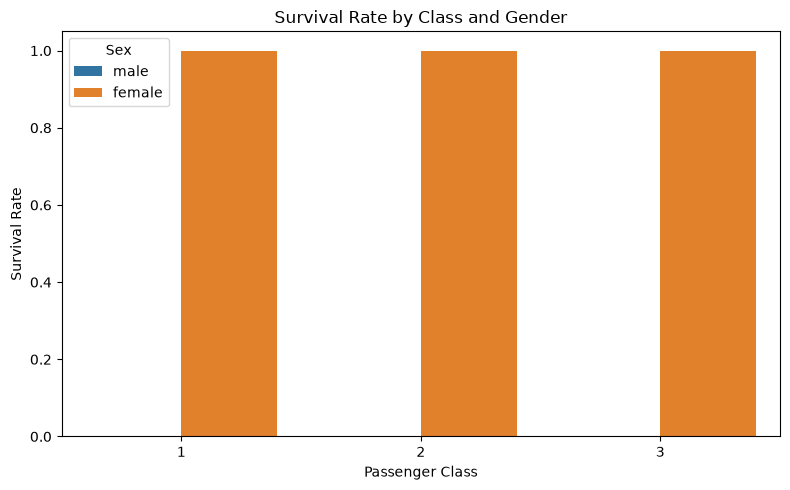

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_class_gender.png", dpi=300)
plt.show()

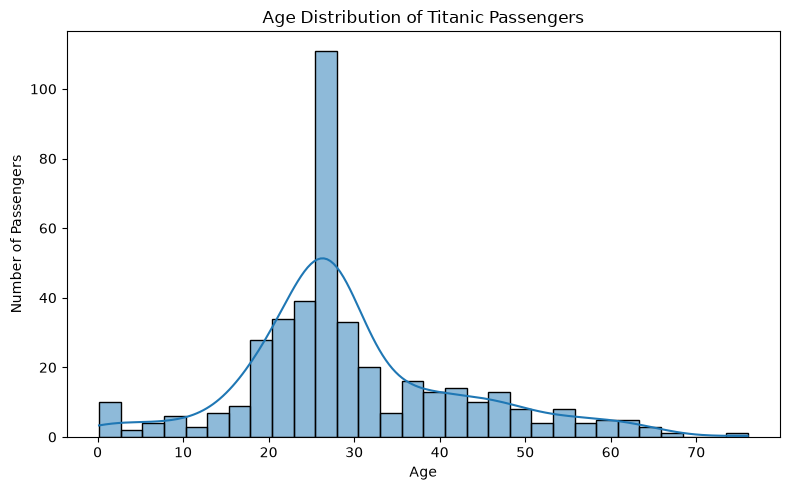

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.savefig("charts/age_distribution.png", dpi=300)
plt.show()

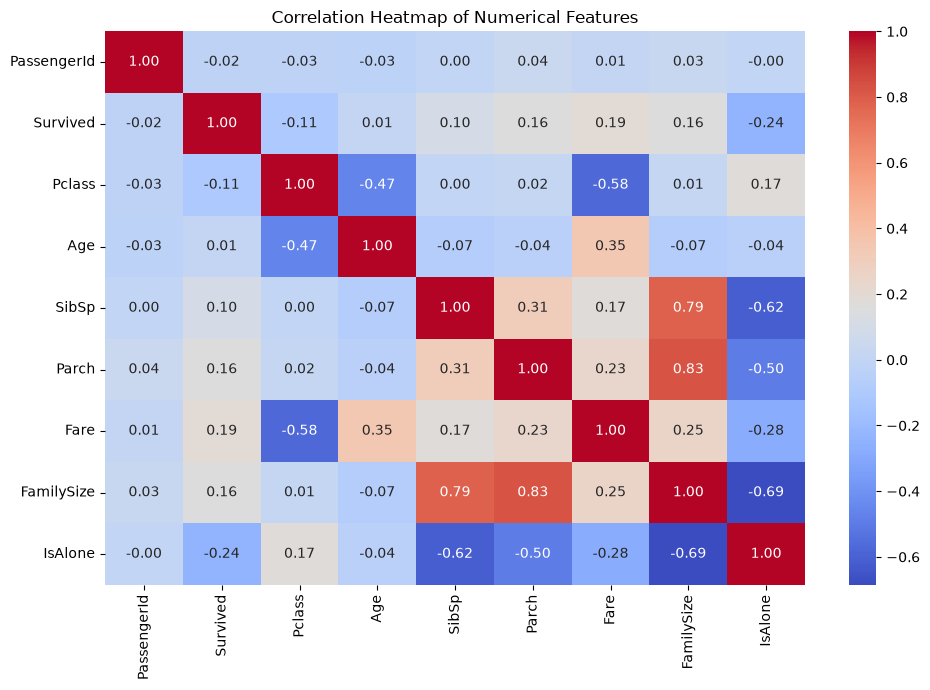

In [17]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=300)
plt.show()

In [18]:
df.to_csv("data/titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
